# L10a · U-Net Segmentation of the Hippocampus in MRI

*Companion notebook for Lecture 10 — Medical Image Analysis (CS184A/284A, AI in Biology and Medicine).*

**Learning objectives**

1. Load 3D MRI volumes and their voxel-wise label masks (NIfTI format).
2. Split the data **by volume before slicing**, so no volume contributes slices to both training and test sets.
3. Build and train a small 2D U-Net (encoder–decoder with skip connections) with a cross-entropy + soft Dice loss.
4. Evaluate with per-volume Dice and IoU, and see why pixel accuracy is misleading for a small foreground.

Notation follows the course guide: image $\mathbf I$, mask $\mathbf Y\in\{0,1\}^{H\times W}$ (one channel per class),
predicted probability map $\mathbf P$, $\mathrm{Dice}=2|A\cap B|/(|A|+|B|)$, $\mathrm{IoU}=|A\cap B|/|A\cup B|$.

**Runtime:** a GPU is recommended: about 2.5 minutes on a CUDA GPU and 4–6 minutes on an Apple-silicon laptop (MPS),
but about 20 minutes on a 4-thread CPU (two U-Nets × 12 epochs of 6,420 slices; roughly 40–80 s per epoch).
On a CPU, lower `epochs` in `train` to 4–6 for a quicker (slightly less accurate) run.

In [1]:
import sys, pathlib, time, json, tarfile, glob
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # course_utils.py lives in applications/
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib            # reads NIfTI (.nii.gz) medical images; pip install nibabel
import torch
import torch.nn as nn
import torch.nn.functional as F
from course_utils import seed_everything, plot_style, download, device, DATA

rng = seed_everything(0)
plot_style()
dev = device()
print("device:", dev)

device: cuda


## 1. Dataset: hippocampus MRI (Medical Segmentation Decathlon, Task 04)

**Biological question.** The hippocampus is a small, curved structure in the medial temporal lobe that is central to
memory. Its volume is studied in Alzheimer's disease, epilepsy and psychiatric disorders — but tracing it by hand on
every MRI slice takes an expert a long time. Can a network draw the outline automatically?

- **What is measured:** T1-weighted structural MRI (3D MPRAGE, 1 mm isotropic voxels). Each voxel's intensity reflects
  tissue relaxation properties (it is *not* a calibrated physical unit, unlike CT).
- **One sample:** one 3D image volume, **cropped around one hippocampus** (about 35 × 50 × 35 voxels).
- **Target:** a label for every voxel: 0 = background, 1 = hippocampus *anterior* (head), 2 = hippocampus *posterior* (body + tail).
- **Cohort:** 90 healthy adults and 105 adults with a non-affective psychotic disorder, Vanderbilt University Medical Center
  (Simpson et al., arXiv:1902.09063). The public training set has 260 labeled volumes; the 195 subjects each appear to
  contribute more than one cropped volume (e.g., left and right), but **the release gives no subject IDs**, so the
  best we can do is split by volume. Keep that caveat in mind.

Source: Medical Segmentation Decathlon (Antonelli et al., *Nature Communications* 13, 4128, 2022), license
**CC-BY-SA 4.0**. We download the MONAI mirror of Task04 (28 MB).

In [2]:
tar_path = download("https://msd-for-monai.s3-us-west-2.amazonaws.com/Task04_Hippocampus.tar")
root = DATA / "Task04_Hippocampus"
if not root.exists():
    with tarfile.open(tar_path) as t:
        t.extractall(DATA, filter="data")
img_files = sorted(p for p in (root / "imagesTr").glob("hippocampus_*.nii.gz"))   # skip macOS '._' files
print(len(img_files), "labeled volumes")

def load(p):
    img = nib.load(str(p)).get_fdata(dtype=np.float32)
    lab = np.asarray(nib.load(str(root / "labelsTr" / p.name)).dataobj).astype(np.int64)
    return img, lab

vols = {p.stem.split(".")[0]: load(p) for p in img_files}
shapes = np.array([v[0].shape for v in vols.values()])
print("volume shape min", shapes.min(0), "max", shapes.max(0))
print("voxel size (mm):", nib.load(str(img_files[0])).header.get_zooms())

260 labeled volumes


volume shape min [31 40 24] max [43 59 47]
voxel size (mm): (np.float32(1.0), np.float32(1.0), np.float32(1.0))


## 2. Exploration: how small is the foreground?

foreground fraction per volume: mean 0.053 (range 0.038–0.075)
anterior 0.027, posterior 0.025


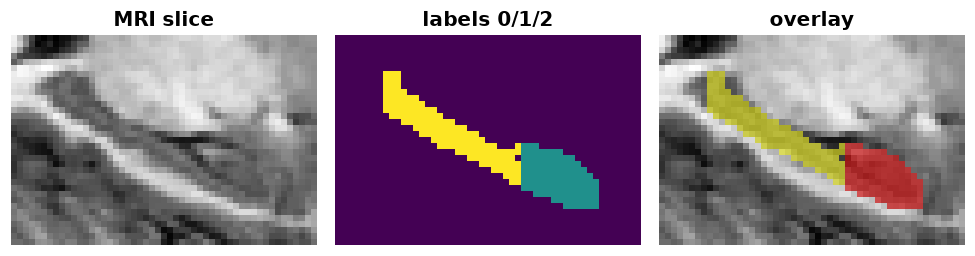

In [3]:
fg = np.array([(lab > 0).mean() for _, lab in vols.values()])
ant = np.array([(lab == 1).mean() for _, lab in vols.values()])
post = np.array([(lab == 2).mean() for _, lab in vols.values()])
print(f"foreground fraction per volume: mean {fg.mean():.3f} (range {fg.min():.3f}–{fg.max():.3f})")
print(f"anterior {ant.mean():.3f}, posterior {post.mean():.3f}")

name0 = list(vols)[0]
img0, lab0 = vols[name0]
k = img0.shape[0] // 2
fig, axes = plt.subplots(1, 3, figsize=(9, 3.4))
axes[0].imshow(img0[k].T, cmap="gray", origin="lower"); axes[0].set_title("MRI slice")
axes[1].imshow(lab0[k].T, cmap="viridis", origin="lower", vmin=0, vmax=2); axes[1].set_title("labels 0/1/2")
axes[2].imshow(img0[k].T, cmap="gray", origin="lower")
axes[2].imshow(np.ma.masked_equal(lab0[k].T, 0), cmap="autumn", alpha=0.5, origin="lower"); axes[2].set_title("overlay")
for a in axes: a.axis("off")
plt.tight_layout(); plt.show()

Even in a crop centered on the hippocampus, only about 5% of voxels are foreground. In a full brain MRI it would be
far less than 1%. This **class imbalance** is why we will use Dice, not accuracy.

## 3. Split by volume first, then slice
If we sliced first and split the slices randomly, neighboring slices of the *same* volume (nearly identical images)
would land in both training and test sets, and the test score would be optimistic. So we split the **volume IDs**
70 / 15 / 15 into train / validation / test, then cut each volume into 2D slices along the first axis
(each slice then contains both the anterior and posterior parts).

In [4]:
names = np.array(sorted(vols))
perm = rng.permutation(len(names))
n_tr, n_va = int(0.7 * len(names)), int(0.15 * len(names))
split = {"train": names[perm[:n_tr]], "val": names[perm[n_tr:n_tr + n_va]], "test": names[perm[n_tr + n_va:]]}
assert not set(split["train"]) & set(split["test"])
print({k: len(v) for k, v in split.items()}, "volumes")

H, W = 64, 48                      # pad slices to a size divisible by 8 (three 2x downsamplings)

def normalize(img):
    lo, hi = np.percentile(img, [1, 99])
    return np.clip((img - lo) / (hi - lo + 1e-6), 0, 1).astype(np.float32)

def pad2d(a):
    out = np.zeros((a.shape[0], H, W), a.dtype)
    out[:, :a.shape[1], :a.shape[2]] = a
    return out

def slices(ids):
    X, Y, V = [], [], []
    for n in ids:
        img, lab = vols[n]
        X.append(pad2d(normalize(img))); Y.append(pad2d(lab)); V += [n] * img.shape[0]
    return np.concatenate(X)[:, None], np.concatenate(Y), np.array(V)

Xtr, Ytr, _ = slices(split["train"])
Xva, Yva, _ = slices(split["val"])
print("training slices:", Xtr.shape, " validation slices:", Xva.shape)

{'train': 182, 'val': 39, 'test': 39} volumes


training slices: (6420, 1, 64, 48)  validation slices: (1378, 1, 64, 48)


Intensities are normalized **per volume** (1st–99th percentile → [0, 1]) because MRI intensities have no fixed scale
across scans. Padding with zeros adds more background; the model learns to ignore it.

## 4. Model: a small 2D U-Net
Encoder: (conv 3×3 → batch norm → ReLU) × 2, then 2×2 max-pool, three times. Decoder: 2×2 transposed convolution
(stride 2) to upsample, **concatenate** the encoder features at the same resolution (skip connection), then two convs.
A final 1×1 conv gives $C = 3$ class scores per pixel; softmax turns them into the probability map $\mathbf P$.

In [5]:
def block(cin, cout):
    return nn.Sequential(nn.Conv2d(cin, cout, 3, padding=1), nn.BatchNorm2d(cout), nn.ReLU(inplace=True),
                         nn.Conv2d(cout, cout, 3, padding=1), nn.BatchNorm2d(cout), nn.ReLU(inplace=True))

class UNet(nn.Module):
    def __init__(self, c_in=1, n_classes=3, base=16, skips=True):
        super().__init__()
        c = [base, 2 * base, 4 * base, 8 * base]
        self.skips = skips
        self.enc = nn.ModuleList([block(c_in, c[0]), block(c[0], c[1]), block(c[1], c[2])])
        self.bottom = block(c[2], c[3])
        self.up = nn.ModuleList([nn.ConvTranspose2d(c[i + 1], c[i], 2, stride=2) for i in (2, 1, 0)])
        self.dec = nn.ModuleList([block(2 * c[i] if skips else c[i], c[i]) for i in (2, 1, 0)])
        self.head = nn.Conv2d(c[0], n_classes, 1)

    def forward(self, x):
        feats = []
        for e in self.enc:
            x = e(x); feats.append(x); x = F.max_pool2d(x, 2)
        x = self.bottom(x)
        for up, dec, f in zip(self.up, self.dec, reversed(feats)):
            x = up(x)
            x = dec(torch.cat([x, f], 1) if self.skips else x)
        return self.head(x)          # logits, shape (B, C, H, W)

model = UNet().to(dev)
print(f"{sum(p.numel() for p in model.parameters()):,} parameters")
with torch.no_grad():
    print("output shape for one slice:", tuple(model(torch.zeros(1, 1, H, W, device=dev)).shape))

483,187 parameters


output shape for one slice: (1, 3, 64, 48)


## 5. Loss: cross-entropy + soft Dice
Pixel cross-entropy is dominated by the many easy background pixels. The **soft Dice loss** works on the probability
map directly and is normalized by the size of each structure, so a small hippocampus counts as much as the background:

$$\mathcal L_{\text{Dice}} = 1 - \frac{1}{|\mathcal C|}\sum_{c\in\mathcal C}\frac{2\sum_j p_{jc}\,y_{jc} + \epsilon}{\sum_j p_{jc} + \sum_j y_{jc} + \epsilon},$$

with $j$ running over pixels in the batch and $\mathcal C$ = the two foreground classes. We add it to the cross-entropy.

In [6]:
def soft_dice_loss(logits, y, eps=1.0):
    P = logits.softmax(1)[:, 1:]                                   # foreground probabilities (B, 2, H, W)
    Y = F.one_hot(y, 3).permute(0, 3, 1, 2)[:, 1:].float()          # one-hot masks
    inter = (P * Y).sum((0, 2, 3))
    denom = P.sum((0, 2, 3)) + Y.sum((0, 2, 3))
    return 1 - ((2 * inter + eps) / (denom + eps)).mean()

def loss_fn(logits, y):
    return F.cross_entropy(logits, y) + soft_dice_loss(logits, y)

## 6. Training
Adam, learning rate $10^{-3}$, mini-batches of 32 slices, random left–right and up–down flips as augmentation.
We keep the weights with the best validation Dice (early stopping, Lecture 8).

In [7]:
def dice_np(a, b):
    s = a.sum() + b.sum()
    return 2 * np.logical_and(a, b).sum() / s if s else 1.0

def iou_np(a, b):
    u = np.logical_or(a, b).sum()
    return np.logical_and(a, b).sum() / u if u else 1.0

@torch.no_grad()
def predict(model, X, bs=256):
    model.eval()
    out = [model(torch.from_numpy(X[i:i + bs]).to(dev)).softmax(1).cpu().numpy() for i in range(0, len(X), bs)]
    return np.concatenate(out)                                        # (N, C, H, W) probability map P

def train(model, epochs=12, bs=32, lr=1e-3, seed=0):
    g = np.random.default_rng(seed)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    Xt, Yt = torch.from_numpy(Xtr), torch.from_numpy(Ytr)
    hist, best, best_state = [], -1, None
    for ep in range(epochs):
        model.train(); t0 = time.time(); tot = 0
        for idx in np.array_split(g.permutation(len(Xt)), len(Xt) // bs):
            x, y = Xt[idx].to(dev), Yt[idx].to(dev)
            if g.random() < 0.5: x, y = x.flip(-1), y.flip(-1)
            if g.random() < 0.5: x, y = x.flip(-2), y.flip(-2)
            loss = loss_fn(model(x), y)
            opt.zero_grad(); loss.backward(); opt.step()
            tot += loss.item() * len(idx)
        pred = predict(model, Xva).argmax(1)
        vd = np.mean([dice_np(pred == c, Yva == c) for c in (1, 2)])
        hist.append((tot / len(Xt), vd))
        if vd > best:
            best, best_state = vd, {k: v.detach().clone() for k, v in model.state_dict().items()}
        print(f"epoch {ep + 1:2d}  train loss {tot / len(Xt):.3f}  val Dice {vd:.3f}  ({time.time() - t0:.0f}s)")
    model.load_state_dict(best_state)
    return np.array(hist)

t_start = time.time()
seed_everything(0)
model = UNet().to(dev)
hist = train(model)
print(f"training time: {time.time() - t_start:.0f}s")

epoch  1  train loss 1.126  val Dice 0.736  (6s)


epoch  2  train loss 0.369  val Dice 0.780  (5s)


epoch  3  train loss 0.232  val Dice 0.828  (5s)


epoch  4  train loss 0.207  val Dice 0.808  (5s)


epoch  5  train loss 0.195  val Dice 0.808  (5s)


...

epoch  8  train loss 0.172  val Dice 0.851  (5s)


epoch  9  train loss 0.164  val Dice 0.850  (4s)


epoch 10  train loss 0.162  val Dice 0.840  (4s)


epoch 11  train loss 0.158  val Dice 0.843  (5s)


epoch 12  train loss 0.157  val Dice 0.847  (4s)
training time: 60s


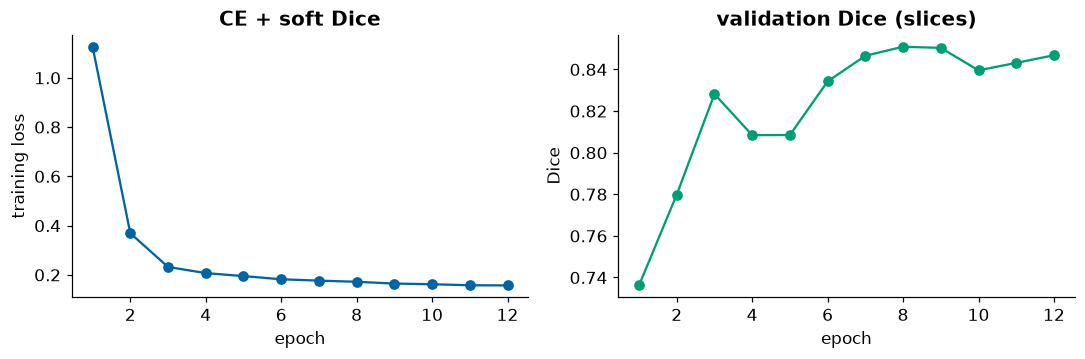

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
ax[0].plot(range(1, len(hist) + 1), hist[:, 0], "o-"); ax[0].set(xlabel="epoch", ylabel="training loss", title="CE + soft Dice")
ax[1].plot(range(1, len(hist) + 1), hist[:, 1], "o-", color="C2"); ax[1].set(xlabel="epoch", ylabel="Dice", title="validation Dice (slices)")
plt.tight_layout(); plt.show()

## 7. Evaluation on held-out volumes
We predict every slice of each **test volume**, stack the slices back into a 3D mask, and compute Dice and IoU
**per volume** (the unit a clinician cares about), then summarize across volumes.

In [9]:
def evaluate(model, ids):
    rows = []
    for n in ids:
        img, lab = vols[n]
        X = pad2d(normalize(img))[:, None]
        pred = predict(model, X).argmax(1)[:, :img.shape[1], :img.shape[2]]
        r = {"volume": n}
        for name, cs in [("anterior", [1]), ("posterior", [2]), ("whole", [1, 2])]:
            a, b = np.isin(pred, cs), np.isin(lab, cs)
            r[f"dice_{name}"], r[f"iou_{name}"] = dice_np(a, b), iou_np(a, b)
        r["pixel_acc"] = (pred == lab).mean()
        r["fg_frac"] = (lab > 0).mean()
        rows.append(r)
    return rows

rows = evaluate(model, split["test"])
summ = {k: (np.mean([r[k] for r in rows]), np.std([r[k] for r in rows])) for k in rows[0] if k != "volume"}
print(f"{len(rows)} test volumes (never seen in training)")
for k in ["dice_anterior", "dice_posterior", "dice_whole", "iou_whole", "pixel_acc"]:
    print(f"  {k:15s} mean {summ[k][0]:.3f} ± {summ[k][1]:.3f} (SD across volumes)")

39 test volumes (never seen in training)
  dice_anterior   mean 0.880 ± 0.030 (SD across volumes)
  dice_posterior  mean 0.863 ± 0.037 (SD across volumes)
  dice_whole      mean 0.893 ± 0.023 (SD across volumes)
  iou_whole       mean 0.808 ± 0.038 (SD across volumes)
  pixel_acc       mean 0.988 ± 0.002 (SD across volumes)


**Dice vs IoU.** For a single mask the two are linked exactly: $\mathrm{IoU} = D/(2-D)$. Check it on one volume:

In [10]:
r = rows[0]
print(f"Dice {r['dice_whole']:.4f} -> D/(2-D) = {r['dice_whole'] / (2 - r['dice_whole']):.4f}, IoU = {r['iou_whole']:.4f}")

Dice 0.9058 -> D/(2-D) = 0.8279, IoU = 0.8279


### Pixel accuracy is misleading
Compare with the trivial model that predicts "background" everywhere:

In [11]:
triv_acc = np.mean([1 - r["fg_frac"] for r in rows])
print(f"all-background predictor: pixel accuracy {triv_acc:.3f}, Dice 0.000")
print(f"U-Net:                    pixel accuracy {summ['pixel_acc'][0]:.3f}, Dice {summ['dice_whole'][0]:.3f}")

all-background predictor: pixel accuracy 0.948, Dice 0.000
U-Net:                    pixel accuracy 0.988, Dice 0.893


The useless predictor already reaches ~95% pixel accuracy on these *cropped* volumes (and >99% on a whole-brain
scan). Dice ignores the true negatives and measures only overlap with the structure we care about.

### Per-volume distribution

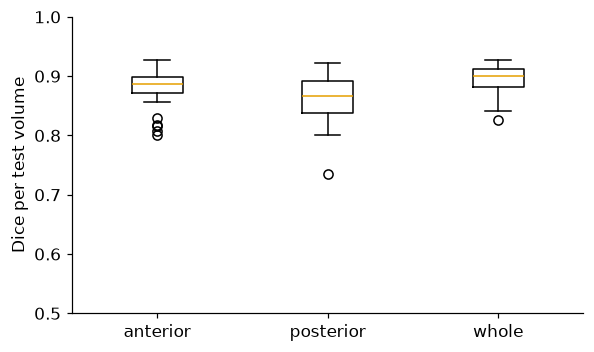

worst volume hippocampus_333 0.826 | best hippocampus_094 0.926


In [12]:
fig, ax = plt.subplots(figsize=(6, 3.5))
d = [[r[f"dice_{k}"] for r in rows] for k in ["anterior", "posterior", "whole"]]
ax.boxplot(d, tick_labels=["anterior", "posterior", "whole"]); ax.set_ylabel("Dice per test volume")
ax.set_ylim(0.5, 1); plt.show()
worst = min(rows, key=lambda r: r["dice_whole"]); best = max(rows, key=lambda r: r["dice_whole"])
print("worst volume", worst["volume"], round(worst["dice_whole"], 3), "| best", best["volume"], round(best["dice_whole"], 3))

## 8. Visualization: overlays on held-out volumes
Green = ground truth outline, magenta fill = prediction. Show the best and the worst test volume.

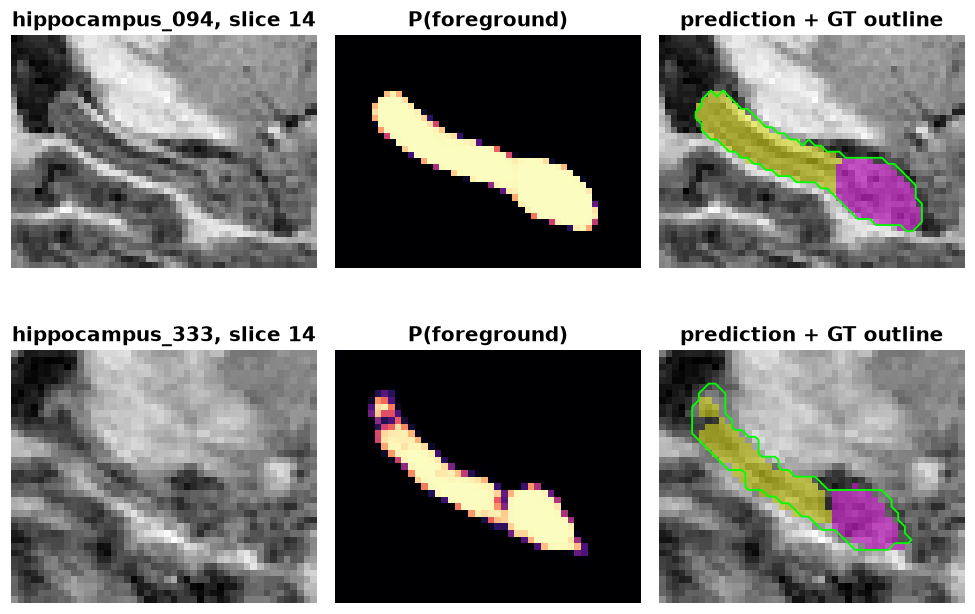

In [13]:
def show(n, ax_row):
    img, lab = vols[n]
    P = predict(model, pad2d(normalize(img))[:, None])[:, :, :img.shape[1], :img.shape[2]]
    pred = P.argmax(1)
    k = int(np.argmax((lab > 0).sum((1, 2))))
    ax_row[0].imshow(img[k].T, cmap="gray", origin="lower"); ax_row[0].set_title(f"{n}, slice {k}")
    ax_row[1].imshow(1 - P[k, 0].T, cmap="magma", origin="lower", vmin=0, vmax=1); ax_row[1].set_title("P(foreground)")
    ax_row[2].imshow(img[k].T, cmap="gray", origin="lower")
    ax_row[2].imshow(np.ma.masked_equal(pred[k].T, 0), cmap="spring", alpha=0.45, origin="lower", vmin=1, vmax=2)
    ax_row[2].contour((lab[k] > 0).T, levels=[0.5], colors="lime", linewidths=1.2)
    ax_row[2].set_title("prediction + GT outline")
    for a in ax_row: a.axis("off")

fig, axes = plt.subplots(2, 3, figsize=(9, 6.5))
show(best["volume"], axes[0]); show(worst["volume"], axes[1])
plt.tight_layout(); plt.show()

Errors concentrate at the **boundary** and at the anterior/posterior junction, where even expert tracings rely on a
landmark convention (the uncal apex) rather than a visible edge.

## 9. Ablation: are the skip connections needed?
Train the same network without skip connections (the decoder sees only the upsampled bottleneck) for the same
number of epochs.

In [14]:
seed_everything(0)
t0 = time.time()
model_noskip = UNet(skips=False).to(dev)
hist_ns = train(model_noskip)
rows_ns = evaluate(model_noskip, split["test"])
print(f"(trained in {time.time() - t0:.0f}s)")
print(f"test Dice (whole): with skips {summ['dice_whole'][0]:.3f}   without skips {np.mean([r['dice_whole'] for r in rows_ns]):.3f}")

epoch  1  train loss 1.288  val Dice 0.592  (5s)


epoch  2  train loss 0.491  val Dice 0.766  (5s)


epoch  3  train loss 0.301  val Dice 0.741  (5s)


epoch  4  train loss 0.266  val Dice 0.802  (5s)


epoch  5  train loss 0.246  val Dice 0.804  (5s)


...

epoch  9  train loss 0.205  val Dice 0.811  (5s)


epoch 10  train loss 0.203  val Dice 0.798  (5s)


epoch 11  train loss 0.199  val Dice 0.802  (5s)


epoch 12  train loss 0.198  val Dice 0.798  (5s)


(trained in 62s)
test Dice (whole): with skips 0.893   without skips 0.862


Without skips the decoder must reconstruct fine boundaries from an 8×6 bottleneck, so outlines get blurrier and Dice drops.

**Numbers vs the lecture slides.** The slides use a run on an Apple-silicon GPU (MPS): Dice anterior 0.880, posterior
0.867, whole 0.895 on 39 test volumes; pixel accuracy 0.988 vs 0.948 for "all background"; no skips 0.857; worst test
volume hippocampus_333 (0.828), best hippocampus_094 (0.924). The same code and seeds on a 4-thread CPU gave 0.879 /
0.869 / 0.895, pixel accuracy 0.988 vs 0.948, no skips 0.860, worst hippocampus_353 (0.840), best hippocampus_094
(0.930). The executed copy of this notebook ran on an NVIDIA L40 GPU: 0.880 / 0.863 / 0.893, pixel accuracy 0.988 vs
0.948, no skips 0.862, worst hippocampus_333 (0.826), best hippocampus_094 (0.926). Floating-point differences between devices change
the training trajectory slightly; the differences (≤ 0.01 Dice) are well below the SD across volumes (≈ 0.02–0.03).

## 10. Save a summary (used by the lecture slides)
The L10 deck reads `applications/data/L10a_results.json` and `L10a_overlays.npz` when it is built; re-running this
notebook overwrites them with the numbers of your run (keep the keys unchanged).

In [15]:
summary = {
    "n_volumes": {k: int(len(v)) for k, v in split.items()},
    "n_train_slices": int(len(Xtr)),
    "n_params": int(sum(p.numel() for p in model.parameters())),
    "epochs": int(len(hist)),
    "fg_frac_mean": float(fg.mean()),
    "test": {k: [float(v[0]), float(v[1])] for k, v in summ.items()},
    "trivial_pixel_acc": float(triv_acc),
    "noskip_dice_whole": float(np.mean([r["dice_whole"] for r in rows_ns])),
    "best": [best["volume"], float(best["dice_whole"])],
    "worst": [worst["volume"], float(worst["dice_whole"])],
    "device": str(dev),
}
(DATA / "L10a_results.json").write_text(json.dumps(summary, indent=1))
# overlays of the best and worst test volume (middle-of-structure slice) for the slides
ov = {}
for tag, r in [("best", best), ("worst", worst)]:
    img, lab = vols[r["volume"]]
    P = predict(model, pad2d(normalize(img))[:, None])[:, :, :img.shape[1], :img.shape[2]]
    k = int(np.argmax((lab > 0).sum((1, 2))))
    ov[f"{tag}_img"], ov[f"{tag}_lab"], ov[f"{tag}_pred"] = img[k], lab[k], P[k].argmax(0)
    ov[f"{tag}_pfg"] = 1 - P[k, 0]
np.savez_compressed(DATA / "L10a_overlays.npz", **ov)
print(json.dumps(summary, indent=1))

{
 "n_volumes": {
  "train": 182,
  "val": 39,
  "test": 39
 },
 "n_train_slices": 6420,
 "n_params": 483187,
 "epochs": 12,
 "fg_frac_mean": 0.052834873738735216,
 "test": {
  "dice_anterior": [
   0.8797687197620646,
   0.02964682881461368
  ],
  "iou_anterior": [
   0.7865598669181906,
   0.04590504498512473
  ],
  "dice_posterior": [
   0.8633231838202042,
   0.037088050471895936
  ],
  "iou_posterior": [
   0.7613312473189171,
   0.055730286250404444
  ],
  "dice_whole": [
   0.893372979217113,
   0.02346111722167385
  ],
  "iou_whole": [
   0.8080891656304104,
   0.03753396236325476
  ],
  "pixel_acc": [
   0.9880374306343797,
   0.0024977420821311676
  ],
  "fg_frac": [
   0.05171446522922089,
   0.005940327176790021
  ]
 },
 "trivial_pixel_acc": 0.9482855347707793,
 "noskip_dice_whole": 0.8617557798360065,
 "best": [
  "hippocampus_094",
  0.9264270068290169
 ],
 "worst": [
  "hippocampus_333",
  0.8260697305863708
 ],
 "device": "cuda"
}


## 11. Biological interpretation and caveats
- A per-volume Dice in the high 0.8s is in the range usually reported for this task, but the **number alone is not
  the clinical endpoint**. Hippocampal *volume* is: compute predicted vs true volume (voxels × 1 mm³) and check for a
  systematic bias (Try it yourself 2).
- The anterior/posterior boundary is defined by a convention, so its Dice is limited by label ambiguity, not only by the model.
- We split by volume, but the release has no subject IDs; crops from the same person could fall on both sides of the split.
  A real study would split **by subject** — and, to claim generality, test on scans from another scanner or site.
- All scans come from one scanner model at one center; performance on other scanners is unknown (domain shift, L10b).

## 12. Try it yourself
1. Train with cross-entropy only (drop the soft Dice term). What happens to the Dice of the smaller structure?
2. Compute predicted vs manual hippocampus volume (in mm³) for each test volume and make a scatter / Bland–Altman plot.
3. Slice along a different axis (e.g., `img[:, k]`). Does Dice change? Why might the anterior/posterior split be harder?
4. Replace `ConvTranspose2d` with `nn.Upsample(scale_factor=2)` followed by a 3×3 conv. Compare Dice and look for checkerboard patterns in $\mathbf P$.
5. *(CS284A)* Write a 3D U-Net (`Conv3d`) on whole volumes (they fit in memory). Is it better than stacking 2D predictions?